# CSC221 GROUP PROJECT

# TEAM: Kaliyah Harris (WORKING SOLO)

### Project Summary:

I decided to Web Scrape data from the best selling Sega games. The source is a Wikipedia site titled "List of best-selling Sega Genesis games" I'll provide the link below this. Some code is referrenced from Lab 8 and other specific parts were used to help fix certain area's. Everything used was refferenced accordingly.

https://en.wikipedia.org/wiki/List_of_best-selling_Sega_Genesis_games

### Importing everything needed to complete the project: 
Importing libraries, BeautifulSoup, Pandas and specifing the webpage we're using.

In [1]:
from urllib.request import Request, urlopen
from bs4 import BeautifulSoup
import pandas as pd

url = "https://en.wikipedia.org/wiki/List_of_best-selling_Sega_Genesis_games"
headers = {'User-Agent': 'Mozilla/5.0'}

rq = Request(url, headers=headers)
page = urlopen(rq).read()

soup = BeautifulSoup(page, "lxml")

### Line below shows the amount of rows in each table:
We'll be taking data from the 2nd table, 1st index.

In [2]:
tables = soup.find_all('table')

for table in tables:
    print(len(table.find_all('tr')))

scrapped_table = tables[1]

8
24
8
5
9
2


### Make sure we're grabbing data from the correct table:

In [3]:
print(len(scrapped_table.find_all('tr')))

24


### Extract data from the table:
**NOTE**:
A problem I ran into was that the wikipedia citations were showing up in my table, I tried to use string replacement first, but that only got rid of the brackets and not the citation numbers. Eventually I found this and used the website provided below to help me fix this problem.

https://www.w3schools.com/python/python_regex.asp

The specific method I used was found here:
https://www.geeksforgeeks.org/python/how-to-remove-brackets-from-text-file-in-python/

I also used this website to help get text from my website, since the method referrenced in Lab 8 wasn't working for me.
https://www.tutorialspoint.com/beautiful_soup/beautiful_soup_get_text_method.htm

In [4]:
import re

A = []
B = []
C = []
D = []
E = []

rows = scrapped_table.find_all('tr')

for row in scrapped_table.find_all('tr'):
    cells = row.find_all('td')

    if len(cells) >= 5:

        text = re.sub(r'\[[^\]]+\]', '', cells[0].get_text(strip=True))
        A.append(text)

        text = re.sub(r'\[[^\]]+\]', '', cells[1].get_text(strip=True))
        B.append(text)

        text = re.sub(r'\[[^\]]+\]', '', cells[2].get_text(strip=True))    
        C.append(text)

        text = re.sub(r'\[[^\]]+\]', '', cells[3].get_text(strip=True))
        D.append(text)

        text = re.sub(r'\[[^\]]+\]', '', cells[4].get_text(strip=True))
        E.append(text)

### Create Dataframe with the data:

In [5]:
df = pd.DataFrame({
    "Title": A,
    "Copies Sold": B,
    "Release Date": C,
    "Developer(s)": D,
    "Publisher(s)": E
    
})

df.head(10)

,Title,Copies Sold,Release Date,Developer(s),Publisher(s)
0,Sonic the Hedgehog,15 million,"June 23, 1991",Sonic Team,Sega
1,Sonic the Hedgehog 2,7.55 million,"November 24, 1992",Sega Technical Institute,Sega
2,Sonic the Hedgehog 3Sonic & Knuckles,6.2million,"February 2, 1994October 18, 1994",Sega Technical InstituteSega Technical Institute,SegaSega
3,Mortal Kombat,4.33 million,"September 13, 1993",Midway,Acclaim Entertainment
4,Disney's Aladdin,4 million,"October 19, 1993",Virgin Games,Sega
5,John Madden Football '93,3million,December 1992,Electronic Arts,Electronic Arts
6,NHL '94,2.6million,September 1993,Electronic Arts,Electronic Arts
7,Joe Montana Football,2.2million,December 1990,Park Place Productions,Sega
8,Jurassic Park,2.2 million,"August 10, 1993",BlueSky Software,Sega
9,NBA Jam,1.93 million,"March 4, 1994",Midway,Acclaim Entertainment


### Print the Table to CSV:

**NOTE**:
If ####'s show up in the csv file just make the columns bigger.

In [6]:
df.head(10).to_csv("CSC221-webscrape-data.csv", index=False)

print("File CSC221-webscrape-data.csv created")

File CSC221-webscrape-data.csv created


# PART TWO:

### Importing necessary packages:

In [3]:
import os
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np

### Reading and Displaying Table Data:

In [8]:
cols = ['Title', 'Copies Sold', 'Release Date', 'Developer(s)', 'Publisher(s)']
DF_SEGAGAMES = pd.read_csv('CSC221-webscrape-data.csv', names=cols)
DF_SEGAGAMES.head(11)

,Title,Copies Sold,Release Date,Developer(s),Publisher(s)
0,Title,Copies Sold,Release Date,Developer(s),Publisher(s)
1,Sonic the Hedgehog,15 million,"June 23, 1991",Sonic Team,Sega
2,Sonic the Hedgehog 2,7.55 million,"November 24, 1992",Sega Technical Institute,Sega
3,Sonic the Hedgehog 3Sonic & Knuckles,6.2million,"February 2, 1994October 18, 1994",Sega Technical InstituteSega Technical Institute,SegaSega
4,Mortal Kombat,4.33 million,"September 13, 1993",Midway,Acclaim Entertainment
5,Disney's Aladdin,4 million,"October 19, 1993",Virgin Games,Sega
6,John Madden Football '93,3million,December 1992,Electronic Arts,Electronic Arts
7,NHL '94,2.6million,September 1993,Electronic Arts,Electronic Arts
8,Joe Montana Football,2.2million,December 1990,Park Place Productions,Sega
9,Jurassic Park,2.2 million,"August 10, 1993",BlueSky Software,Sega


### Create a graph displaying the data:

### Graph of choice:

My Graph of choice was a bar graph, I felt like a bar graph could properly display and show the difference between the 1st most popular game and the 10th most popular game. A vertical bar graph was my first choice, but since the title of the games were so long it was impossible to read.

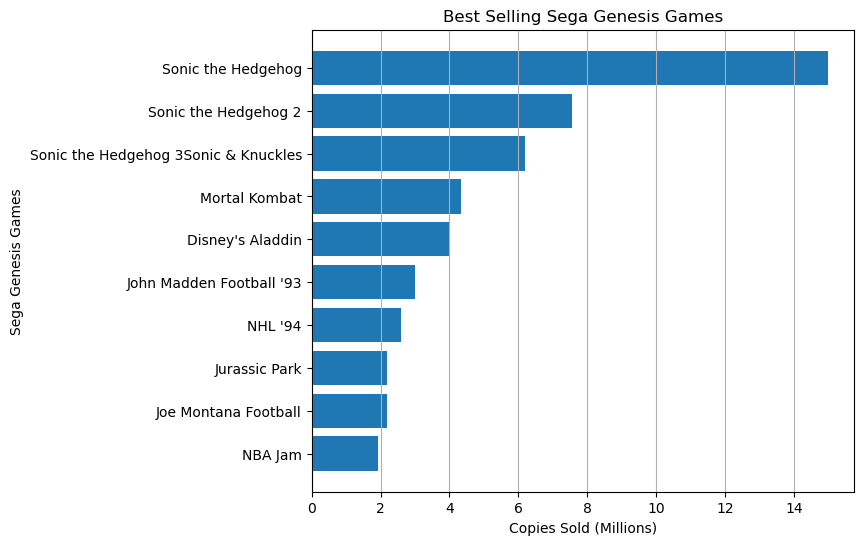

In [4]:
#Removes the header row problem I ran into, The title was taking up a spot in the graph
DF_SEGAGAMES = DF_SEGAGAMES[DF_SEGAGAMES['Title'] != 'Title']

#Clean the 'Copies Sold' column since they didn't have numerical data
#I had to convert the strings to floats to be able to graph it
DF_SEGAGAMES['Copies Sold'] = (
    DF_SEGAGAMES['Copies Sold']
    .astype(str)
    .str.replace('million', '', regex=False)
    .str.strip()
    .astype(float)

)

#Takes the first ten columns
df = DF_SEGAGAMES.iloc[0:10]

#Sorts the table since I ran into a problem of smaller values, looking bigger on the graph
df = df.sort_values(by='Copies Sold')

#Plot the bar graph, Vertical did not have enough room to fit all titles
plt.figure(figsize=(7, 6))
plt.barh(df['Title'], df['Copies Sold'])

plt.xlabel('Copies Sold (Millions)')
plt.ylabel('Sega Genesis Games')
plt.title('Best Selling Sega Genesis Games')

plt.grid(axis='x')
plt.show()

### Problems I ran into:
(With referenced Solutions)

The first problem where I had to look up was the data not being able to accurately be plotted because the data wasn't numerical. The link referenced below helped me convert the strings to floats.

 * Cleaned the columns: https://pandas.pydata.org/docs/reference/api/pandas.Series.str.replace.html
 * Cleaned the columns source 2: https://www.geeksforgeeks.org/pandas/python-pandas-series-str-replace-to-replace-text-in-a-series/
 * Converting String to a Float: https://www.geeksforgeeks.org/python/how-to-convert-strings-to-floats-in-pandas-dataframe/

The second problem where I had to look up was the Graph itself not accurately displaying the bigger values, the link below helped me sort the Games so that the most sold game was on top, while also making sure the bars displayed the amount of copies sold.

 * Sorted the table: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sort_values.html
